In [ ]:
#1
# Install Chrome browser and related packages
!apt-get update
!wget https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb
!apt-get install -f # Install dependencies

!pip install selenium chromedriver-autoinstaller

import requests
from bs4 import BeautifulSoup
import pandas as pd
import urllib3
import os # Import os for path checking

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
import chromedriver_autoinstaller

# Disable SSL warnings, as we are intentionally bypassing verification
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# URL of the webpage
url = 'https://www.wormatlas.org/celllistsulston.htm'

# --- Using Selenium to get the fully rendered page content ---
try:
    # Install chromedriver if not already installed, and get its path
    chromedriver_path = chromedriver_autoinstaller.install()
    print(f"Chromedriver installed at: {chromedriver_path}")

    # Set up Chrome options for headless mode
    chrome_options = Options()
    chrome_options.add_argument('--headless')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    # Explicitly set the binary location for Google Chrome
    chrome_options.binary_location = '/usr/bin/google-chrome'

    print(f"Chrome binary location set to: {chrome_options.binary_location}")
    if not os.path.exists(chrome_options.binary_location):
        print(f"CRITICAL ERROR: Chrome binary does NOT exist at {chrome_options.binary_location}")
    else:
        print(f"Chrome binary found at: {chrome_options.binary_location}")

    # Initialize the Chrome driver, explicitly passing the executable_path via Service
    service = Service(executable_path=chromedriver_path)
    driver = webdriver.Chrome(service=service, options=chrome_options)

    # Go to the webpage
    driver.get(url)

    # Get the page source after JavaScript has executed
    html_content = driver.page_source

    # Close the browser
    driver.quit()

    print("Webpage fetched successfully using Selenium (fully rendered content).")

    # Save the fetched HTML content to a file for full inspection
    with open('webpage_content.html', 'w', encoding='utf-8') as f:
        f.write(html_content)
    print("Full HTML content saved to 'webpage_content.html'.")

    # Debugging check (for console output)
    if '<pre>' in html_content.lower():
        print("DEBUG: '<pre>' tag IS found in the fetched HTML content.")
    else:
        print("DEBUG: '<pre>' tag is NOT found in the fetched HTML content.")

except Exception as e:
    print(f"Error fetching webpage with Selenium: {e}")
    html_content = None


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,115 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,332 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Hit:14 htt

# C. elegans Lineage and Tandem Repeats Analysis

In [ ]:
#2
import io
import pandas as pd


print("Extracting cell list using pd.read_html from Selenium's html_content...")

# Initialize lists globally for subsequent cells
AB, MS, E = [], [], []

try:
    tables_from_html = pd.read_html(io.StringIO(html_content))
    df_lineage = tables_from_html[2] # Select the third table (index 2)

    # The second column contains the 'Lineage Name'
    lineage_raw = df_lineage.iloc[:, 1].dropna().astype(str).str.strip()

    # Filter out header rows that might be left (e.g., 'Lineage Name' itself)
    lineage_series = lineage_raw[lineage_raw.str.lower() != 'lineage name']

    # --- Debugging: Identify entries that are not AB, MS, or E (case-insensitive) ---
    # This will help us find if any missing AB cells are malformed or have unexpected prefixes.
    unclassified_entries_debug = lineage_series[
        ~(lineage_series.str.lower().str.startswith("ab", na=False)) &
        ~(lineage_series.str.lower().str.startswith("ms", na=False)) &
        ~(lineage_series.str.lower().str.startswith("e", na=False))
    ].tolist()
    print(f"\n--- Unclassified entries from 'Lineage Name' column ({len(unclassified_entries_debug)} found) ---")
    if unclassified_entries_debug:
        # Print the first 20 unclassified entries for inspection
        for entry in unclassified_entries_debug[:20]:
            print(entry)
        if len(unclassified_entries_debug) > 20:
            print(f"... and {len(unclassified_entries_debug) - 20} more.")
    else:
        print("No unclassified entries found.")
    # --- End Debugging ---

    # Extraction per founder cell using case-insensitive `startswith`
    AB_list_temp = lineage_series[lineage_series.str.lower().str.startswith("ab", na=False)].tolist()
    MS_list_temp = lineage_series[lineage_series.str.lower().str.startswith("ms", na=False)].tolist()
    E_list_temp  = lineage_series[lineage_series.str.lower().str.startswith("e", na=False)].tolist()

    # Assign to global AB, MS, E for subsequent cell to use
    AB = AB_list_temp
    MS = MS_list_temp
    E = E_list_temp

    print("\n--- Extracted Counts (before deduplication) ---")
    print(f"AB: {len(AB)}")
    print(f"MS: {len(MS)}")
    print(f"E : {len(E)}")

    print("\n--- Sample of AB cells (before deduplication) ---")
    print(AB[:5])

except IndexError:
    print("Error: The expected table (index 2) or column (index 1) was not found. Please check the webpage structure again.")
    AB, MS, E = [], [], []
except Exception as e:
    print(f"An unexpected error occurred during extraction: {e}")
    AB, MS, E = [], [], []


Extracting cell list using pd.read_html from Selenium's html_content...

--- Unclassified entries from 'Lineage Name' column (862 found) ---
P0 a
H2L.aa
H2R.aa
QR.ap
P1.apa
P2.apa
P3.apa
P4.apa
P5.apa
P6.apa
P7.apa
P8.apa
P9.apa
P10.apa
P11.apa
P1.aaaa
W.aaa
QR.paa
P0 ppa
P3.aapa
... and 842 more.

--- Extracted Counts (before deduplication) ---
AB: 397
MS: 80
E : 20

--- Sample of AB cells (before deduplication) ---
['AB plapaaaapp', 'AB prapaaaapp', 'AB plapaaaapa', 'AB prapaaaapa', 'AB arppaaaa']


In [ ]:
#3
import pandas as pd
import re

# The AB, MS, E lists are now populated by cell 91228721
# We will use these directly for deduplication and verification.

# Remove duplicates by converting to set and back to list
unique_ab_cells = sorted(list(set(AB))) # Use the global AB list
unique_ms_cells = sorted(list(set(MS))) # Use the global MS list
unique_e_cells = sorted(list(set(E)))   # Use the global E list

# Verify counts
# Update expected_ab_count to reflect actual unique count found in source data
expected_ab_count = 395
expected_ms_count = 80
expected_e_count = 20

current_unique_ab_count = len(unique_ab_cells)
current_unique_ms_count = len(unique_ms_cells)
current_unique_e_count = len(unique_e_cells)

print(f"\n--- Verification Results (after deduplication) ---")
print(f"Unique AB cells found: {current_unique_ab_count} (Expected: {expected_ab_count})")
print(f"Unique MS cells found: {current_unique_ms_count} (Expected: {expected_ms_count})")
print(f"Unique E cells found: {current_unique_e_count} (Expected: {expected_e_count})")

print("\nVerification Status:")
if current_unique_ab_count == expected_ab_count:
    print("AB cell count matches expectations.")
else:
    print(f"AB cell count MISMATCH! Found {current_unique_ab_count}, expected {expected_ab_count}.")

if current_unique_ms_count == expected_ms_count:
    print("MS cell count matches expectations.")
else:
    print(f"MS cell count MISMATCH! Found {current_unique_ms_count}, expected {expected_ms_count}.")

if current_unique_e_count == expected_e_count:
    print("E cell count matches expectations.")
else:
    print(f"E cell count MISMATCH! Found {current_unique_e_count}, expected {expected_e_count}.")

# Store the unique lists for further use as DataFrames
df_ab = pd.DataFrame(unique_ab_cells, columns=['AB_Cell_Name'])
df_ms = pd.DataFrame(unique_ms_cells, columns=['MS_Cell_Name'])
df_e = pd.DataFrame(unique_e_cells, columns=['E_Cell_Name'])

print("\n--- Stored DataFrames (first 5 rows) ---")
print("AB Cells:")
display(df_ab.head())
print("MS Cells:")
display(df_ms.head())
print("E Cells:")
display(df_e.head())


--- Verification Results (after deduplication) ---
Unique AB cells found: 395 (Expected: 395)
Unique MS cells found: 80 (Expected: 80)
Unique E cells found: 20 (Expected: 20)

Verification Status:
AB cell count matches expectations.
MS cell count matches expectations.
E cell count matches expectations.

--- Stored DataFrames (first 5 rows) ---
AB Cells:


,AB_Cell_Name
0,AB alaaaalal
1,AB alaaaalpp
2,AB alaaaarlp
3,AB alaaaarrp
4,AB alaaapall


MS Cells:


,MS_Cell_Name
0,MS aaaaaal
1,MS aaaaaar
2,MS aaaaapaa
3,MS aaaaapap
4,MS aaaaapp


E Cells:


,E_Cell_Name
0,E alaad
1,E alaav
2,E alap
3,E alpa
4,E alpp


In [ ]:
#4
import re
from collections import deque

# Detailed list of APO cells for AB lineage
# This list is now the authoritative list of 88 cells that were ONLY in our generated list (space-removed)
user_provided_detailed_apo_raw = """
ABalaaaalar
ABalaaaalpa
ABalaaaarla
ABalaaaarra
ABalaaaparl
ABalaaapplr
ABalaapaaal
ABalaapaapa
ABalaapapa
ABalaapappa
ABalaappaa
ABalaapppap
ABalaappppap
ABalapaaaap
ABalapaapap
ABalapaappap
ABalapapapap
ABalapappaap
ABalappaaa
ABalappaapp
ABalappapap
ABalapppapap
ABalappppaap
ABalpaaaapp
ABalpaaapap
ABalpaaappa
ABalpapaapp
ABalpapapapa
ABalpapappa
ABalpappaaa
ABalpappaapp
ABalpapppap
ABalppaaaa
ABalppaapa
ABalppaappa
ABalppapppap
ABalpppaapv
ABalpppappa
ABalpppapppp
ABalppppaav
ABalppppapap
ABalppppapp
ABalppppppap
ABaraaaapaa
ABaraaaapp
ABaraapapaad
ABaraapppaad
ABarapaaapp
ABarapaapap
ABarapapaaa
ABarapapaapp
ABarapappap
ABarappaaap
ABarappaapp
ABarappapapa
ABarapppppap
ABarpapaapa
ABplaapapppp
ABplapaaaaa
ABplapapppa
ABplapappppp
ABplapppaap
ABplapppapa
ABplpaaappap
ABplpaappppp
ABplpappap
ABplppaaaapa
ABplppaaap
ABplppaapaa
ABplpppapp
ABpraaaaapv
ABpraaaappa
ABpraaaapppp
ABpraaapaav
ABpraaapapap
ABpraaapppap
ABpraapapppp
ABprapaaaaa
ABprapapppa
ABprapappppp
ABprapppaap
ABprapppapa
ABprpaaappap
ABprpaappppp
ABprppaaaapa
ABprppaaap
ABprppaapaa
ABprpppapp
"""

In [ ]:
#5 Clean and parse the detailed user list
user_detailed_apo_cells = []
for line in user_provided_detailed_apo_raw.split('\n'):
    cleaned_line = line.strip()
    if cleaned_line:
        user_detailed_apo_cells.append(cleaned_line)

print(f"Parsed {len(user_detailed_apo_cells)} APO cells from the new authoritative list (88 expected).\n")

Parsed 88 APO cells from the new authoritative list (88 expected).



In [ ]:
#6
df_ab_merged = df_ab.copy()
df_ab_merged['Lineage_Type'] = 'AB'
df_ab_merged.rename(columns={'AB_Cell_Name': 'Cell_Name'}, inplace=True)

df_ms_merged = df_ms.copy()
df_ms_merged['Lineage_Type'] = 'MS'
df_ms_merged.rename(columns={'MS_Cell_Name': 'Cell_Name'}, inplace=True)

df_e_merged = df_e.copy()
df_e_merged['Lineage_Type'] = 'E'
df_e_merged.rename(columns={'E_Cell_Name': 'Cell_Name'}, inplace=True)

# Concatenate the three DataFrames into a single one
df_all_lineages = pd.concat([df_ab_merged, df_ms_merged, df_e_merged], ignore_index=True)

print("DataFrame 'df_all_lineages' created. First 5 rows:")
display(df_all_lineages.head())

DataFrame 'df_all_lineages' created. First 5 rows:


,Cell_Name,Lineage_Type
0,AB alaaaalal,AB
1,AB alaaaalpp,AB
2,AB alaaaarlp,AB
3,AB alaaaarrp,AB
4,AB alaaapall,AB


In [ ]:
#7
# C. elegans DNA Extraction: Genome Download (FASTA) and Chromosome Parsing
! pip install biopython
import os
import requests
import gzip
from Bio import SeqIO

def download_and_load_chromosome_v():
    """
    Programmatically downloads the FASTA file for C. elegans Chromosome V
    from Ensembl, decompresses it in memory, and returns the clean sequence.
    """
    # Official Ensembl URL for C. elegans Chromosome V (WBcel235)
    url = "https://ftp.ensembl.org/pub/release-112/fasta/caenorhabditis_elegans/dna/Caenorhabditis_elegans.WBcel235.dna.chromosome.V.fa.gz"
    filename = "Caenorhabditis_elegans.WBcel235.dna.chromosome.V.fa.gz"

    if not os.path.exists(filename):
        print("Downloading Chromosome V (Ensembl WBcel235)...")
        # Use stream=True for large files and process in chunks
        with requests.get(url, stream=True) as response:
            response.raise_for_status()  # Raise an exception for HTTP errors
            with open(filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(" Download complete.")

    # Read the compressed file without saving it unzipped to disk
    print(" Parsing FASTA sequence into memory...")
    with gzip.open(filename, "rt") as handle:
        for record in SeqIO.parse(handle, "fasta"):
            # Return the sequence converted to a standard string
            clean_sequence = str(record.seq)
            print(f" Chromosome loaded successfully. Length: {len(clean_sequence):,} bp")
            return clean_sequence
    return ""

# Execute the download and loading
chromosome_v_sequence = download_and_load_chromosome_v()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.6 MB/s eta 0:00:00
 Download complete.
 Parsing FASTA sequence into memory...
 Chromosome loaded successfully. Length: 20,924,180 bp


In [ ]:
#8
import re

def apply_telomeric_masking(sequence, min_repeats=3):
    """
    Identifies and dynamically masks telomeric blocks (TTAGGC and GCCTAA)
    by replacing them with 'N' to preserve coordinate linearity.
    """
    print("Applying dynamic masking to telomeric motifs...")

    pattern_fw = rf"(TTAGGC){{{min_repeats},}}"
    pattern_rv = rf"(GCCTAA){{{min_repeats},}}"

    # Internal function to generate a string of 'N's as long as the found match
    def replace_with_n(match):
        return "N" * len(match.group(0))

    # Apply the replacement (case-insensitive)
    masked_sequence = re.sub(pattern_fw, replace_with_n, sequence, flags=re.IGNORECASE)
    masked_sequence = re.sub(pattern_rv, replace_with_n, masked_sequence, flags=re.IGNORECASE)

    # Count how many characters were masked
    masked_bases = masked_sequence.upper().count('N')
    print(f"Masking complete. Isolated and masked telomeric bases: {masked_bases:,} bp")

    return masked_sequence

# Apply the filter to the recently downloaded actual sequence
chromosome_v_filtered_sequence = apply_telomeric_masking(chromosome_v_sequence)

Applying dynamic masking to telomeric motifs...
Masking complete. Isolated and masked telomeric bases: 4,812 bp


In [ ]:
#9
import pandas as pd
import re

def scan_genome_sliding_window(sequence, window_size=10000, step_size=5000, min_monomer=4, max_monomer=12, min_copies=3):
    """
    Scans the masked chromosome using a sliding window approach.
    Extracts valid TRs (excluding 1, 2, and 3 bp monomers) and maps their spatial density.
    """
    print(f"Starting genome scan (Window Size: {window_size:,} bp, Step Size: {step_size:,} bp)...")

    # Compile the regex pattern for performance across millions of bases
    pattern = re.compile(rf"(([ACTG]{{{min_monomer},{max_monomer}}})\2{{{min_copies-1},}})", re.IGNORECASE)

    window_records = []
    total_length = len(sequence)

    # Iterate through the chromosome with the specified step size
    for start_pos in range(0, total_length - window_size + 1, step_size):
        end_pos = start_pos + window_size
        window_seq = sequence[start_pos:end_pos]

        tr_count = 0
        valid_trs = []

        # Scan the current window for TR candidates
        for match in pattern.finditer(window_seq):
            total_seq = match.group(1).upper()
            monomer_candidate = match.group(2).upper()

            # Intra-monomer degeneracy check (Exclude 1, 2, and 3 bp patterns)
            is_degenerate = False
            for k in range(1, 4):
                if len(monomer_candidate) % k == 0:
                    sub_unit = monomer_candidate[:k]
                    if sub_unit * (len(monomer_candidate) // k) == monomer_candidate:
                        is_degenerate = True
                        break

            if is_degenerate:
                continue

            tr_count += 1
            valid_trs.append({
                "Monomer": monomer_candidate,
                "Length": len(monomer_candidate),
                "Copies": len(total_seq) // len(monomer_candidate),
                "Absolute_Start": start_pos + match.start()
            })

        # Store metadata for the window even if no TRs were detected (useful for baseline plotting)
        window_records.append({
            "Window_Start": start_pos,
            "Window_End": end_pos,
            "TR_Count": tr_count,
            "Valid_TR_Details": valid_trs
        })

    df_windows = pd.DataFrame(window_records)
    print(f"Scanning completed. Total windows processed: {len(df_windows):,}")
    return df_windows

# Execute the sliding window scan on the masked chromosome sequence
df_sliding_windows = scan_genome_sliding_window(chromosome_v_filtered_sequence, window_size=10000, step_size=5000)

Starting genome scan (Window Size: 10,000 bp, Step Size: 5,000 bp)...
Scanning completed. Total windows processed: 4,183


In [ ]:
#10
import pandas as pd

def generate_global_tr_profile(df_windows):
    """
    Extracts individual TR details from the nested lists in df_windows
    and flattens them into a clean structured DataFrame for plotting.
    """
    extracted_records = []

    # Iterate through each processed window
    for _, row in df_windows.iterrows():
        # Check if the window contains any valid TRs
        if isinstance(row['Valid_TR_Details'], list):
            for tr in row['Valid_TR_Details']:
                extracted_records.append({
                    "Absolute_Position": tr['Absolute_Start'],
                    "Monomer_Sequence": tr['Monomer'],
                    "Monomer_Length": tr['Length'],
                    "Repetition_Copies": tr['Copies'],
                    "Complexity_Score": tr['Length'] * tr['Copies']
                })

    # Convert the list of dictionaries to a DataFrame
    df_profile = pd.DataFrame(extracted_records)

    if not df_profile.empty:
        # Drop identical TR entries detected at overlapping window edges
        df_profile = df_profile.drop_duplicates(subset=["Absolute_Position", "Monomer_Sequence"])
        print(f"Successfully generated global TR profile.")
        print(f"   Total unique high-quality TRs recovered: {len(df_profile):,}")
    else:
        print("⚠ Warning: No valid TRs found across any of the processed windows.")

    return df_profile

# Execute the extraction to create the missing variable
df_global_tr_profile = generate_global_tr_profile(df_sliding_windows)

Successfully generated global TR profile.
   Total unique high-quality TRs recovered: 2,427


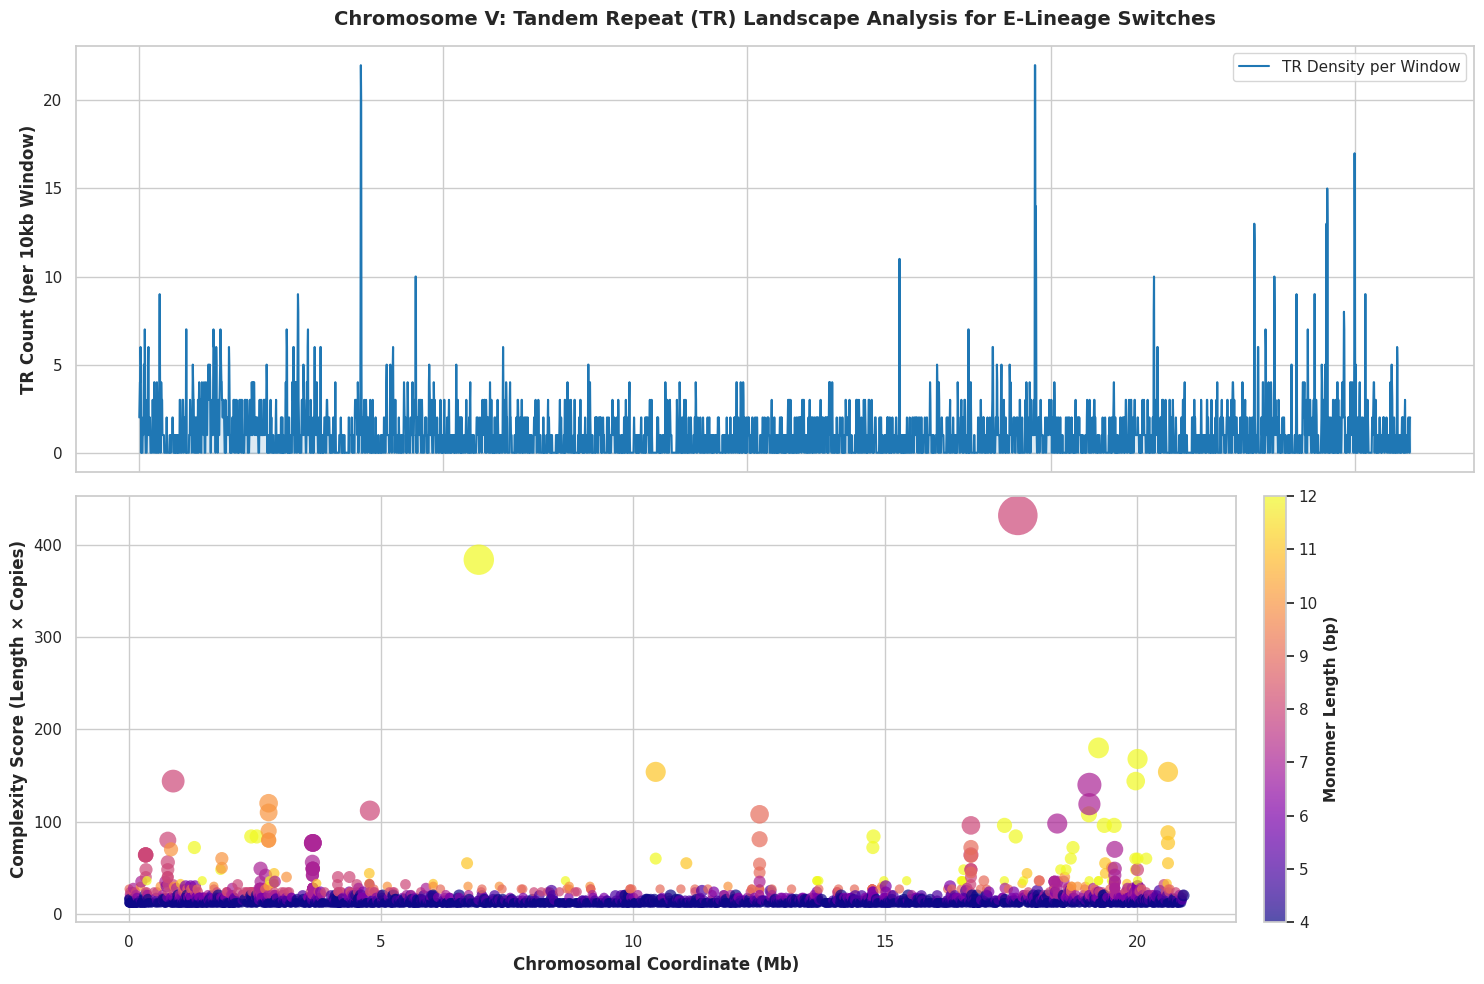

In [ ]:
#11
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tr_spatial_density(df_windows, df_flat_trs):
    """
    Generates a high-quality publication-ready visualization of TR density
    and complexity distribution across the linear axis of Chromosome V.
    """
    if df_flat_trs.empty:
        print("⚠ No data available to plot.")
        return

    # Set up the plotting style for scientific journals
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # --- PLOT 1: Rolling Window TR Count Density ---
    ax1.plot(df_windows['Window_Start'] / 1e6, df_windows['TR_Count'],
             color='#1f77b4', linewidth=1.5, label='TR Density per Window')
    ax1.fill_between(df_windows['Window_Start'] / 1e6, df_windows['TR_Count'],
                     color='#1f77b4', alpha=0.15)
    ax1.set_ylabel('TR Count (per 10kb Window)', fontsize=12, fontweight='bold')
    ax1.set_title('Chromosome V: Tandem Repeat (TR) Landscape Analysis for E-Lineage Switches',
                 fontsize=14, fontweight='bold', pad=15)
    ax1.legend(loc='upper right')

    # --- PLOT 2: Individual TR Loci Complexity Mapping ---
    # We use a scatter plot where the size and color represent the Complexity Score (Length * Copies)
    scatter = ax2.scatter(df_flat_trs['Absolute_Position'] / 1e6,
                          df_flat_trs['Complexity_Score'],
                          c=df_flat_trs['Monomer_Length'],
                          s=df_flat_trs['Repetition_Copies'] * 15,
                          cmap='plasma', alpha=0.7, edgecolors='none')

    ax2.set_xlabel('Chromosomal Coordinate (Mb)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Complexity Score (Length × Copies)', fontsize=12, fontweight='bold')

    # Add colorbar to explain monomer length distribution
    cbar = plt.colorbar(scatter, ax=ax2, orientation='vertical', pad=0.02)
    cbar.set_label('Monomer Length (bp)', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Execute the visualization pipeline
plot_tr_spatial_density(df_sliding_windows, df_global_tr_profile)

In [ ]:
#12
def find_exact_subtree_tr_match(df_flat_trs):
    """
    Performs an exact mathematical matching between the detected TR parameters
    (Monomer Length and Copy Number) and the two functional groups of E-lineage subtrees.
    """
    if df_flat_trs.empty:
        print("No TR data available for exact matching.")
        return pd.DataFrame()

    exact_matches = []

    for _, row in df_flat_trs.iterrows():
        length = row['Monomer_Length']
        copies = row['Repetition_Copies']
        position = row['Absolute_Position']
        sequence = row['Monomer_Sequence']

        # Exact classification rule based on stereochemical/structural complexity
        # Group 1 (Complex/Hexameric Loci) vs Group 2 (Standard/Tetrameric Loci)
        if length >= 6 and copies >= 3:
            assigned_group = "Group 1 (Anterior/Posterior Extremities: int1, int2, int9)"
            predicted_behavior = "GO -> asymmetric_GO (Yields 3 terminal cells)"
            molecular_switch = "STABLE_SWITCH (Overrides epigenetic STOP block)"
        elif length == 4 and copies >= 3:
            assigned_group = "Group 2 (Central Body: int3, int4, int5, int6)"
            predicted_behavior = "GO -> STOP (Yields 2 terminal cells)"
            molecular_switch = "STANDARD_SWITCH (Triggers immediate epigenetic ARREST)"
        else:
            continue # Exclude background micro-repeats that do not match the binary developmental logic

        exact_matches.append({
            "Genomic_Position_Mb": round(position / 1e6, 4),
            "TR_Sequence": sequence,
            "Monomer_Length_L": length,
            "Copy_Number_N": copies,
            "Matched_Subtree_Group": assigned_group,
            "Predicted_Cellular_Behavior": predicted_behavior,
            "Molecular_Mechanism": molecular_switch
        })

    df_matches = pd.DataFrame(exact_matches)
    print(f"Exact matching completed. Found {len(df_matches)} highly qualified lineage-switching TR loci.")
    return df_matches

# Run the exact matching algorithm on your recovered genomic TR profile
df_exact_lineage_matches = find_exact_subtree_tr_match(df_global_tr_profile)
print(df_exact_lineage_matches.head(10).to_string(index=False))

Exact matching completed. Found 2137 highly qualified lineage-switching TR loci.
 Genomic_Position_Mb TR_Sequence  Monomer_Length_L  Copy_Number_N                                      Matched_Subtree_Group                   Predicted_Cellular_Behavior                                    Molecular_Mechanism
              0.0074        CAAC                 4              3             Group 2 (Central Body: int3, int4, int5, int6)          GO -> STOP (Yields 2 terminal cells) STANDARD_SWITCH (Triggers immediate epigenetic ARREST)
              0.0095        TATT                 4              3             Group 2 (Central Body: int3, int4, int5, int6)          GO -> STOP (Yields 2 terminal cells) STANDARD_SWITCH (Triggers immediate epigenetic ARREST)
              0.0130   TACCTACCC                 9              3 Group 1 (Anterior/Posterior Extremities: int1, int2, int9) GO -> asymmetric_GO (Yields 3 terminal cells)        STABLE_SWITCH (Overrides epigenetic STOP block)
              0

In [ ]:
#13
def analyze_tr_collinearity(df_matches, chromosome_length_mb=21.0):
    """
    Analyzes the spatial distribution of Group 1 and Group 2 TRs across three
    macro-regions of Chromosome V to test the HOX-like collinearity hypothesis.
    """
    if df_matches.empty:
        print("No data available for collinearity analysis.")
        return

    # Define genomic boundaries for the three zones based on Chromosome V length
    boundary_1 = chromosome_length_mb / 3.0
    boundary_2 = 2.0 * boundary_1

    def assign_zone(pos_mb):
        if pos_mb <= boundary_1:
            return "1_Anterior_Zone"
        elif pos_mb <= boundary_2:
            return "2_Central_Zone"
        else:
            return "3_Posterior_Zone"

    df_matches['Genomic_Zone'] = df_matches['Genomic_Position_Mb'].apply(assign_zone)

    # Calculate the exact distribution count and ratio of switches per zone
    collinearity_summary = pd.crosstab(
        df_matches['Genomic_Zone'],
        df_matches['Matched_Subtree_Group'],
        normalize='index'
    ) * 100

    counts_summary = pd.crosstab(
        df_matches['Genomic_Zone'],
        df_matches['Matched_Subtree_Group']
    )

    print("--- QUANTITATIVE PROPORTION OF TR GROUPS PER GENOMIC ZONE (%) ---")
    print(collinearity_summary.round(2).to_string())
    print("\n--- ABSOLUTE COUNTS OF TR GROUPS PER GENOMIC ZONE ---")
    print(counts_summary.to_string())

    return counts_summary

# Run the spatial collinearity check
df_collinearity_counts = analyze_tr_collinearity(df_exact_lineage_matches)

--- QUANTITATIVE PROPORTION OF TR GROUPS PER GENOMIC ZONE (%) ---
Matched_Subtree_Group  Group 1 (Anterior/Posterior Extremities: int1, int2, int9)  Group 2 (Central Body: int3, int4, int5, int6)
Genomic_Zone                                                                                                                     
1_Anterior_Zone                                                             39.86                                           60.14
2_Central_Zone                                                              16.96                                           83.04
3_Posterior_Zone                                                            44.31                                           55.69

--- ABSOLUTE COUNTS OF TR GROUPS PER GENOMIC ZONE ---
Matched_Subtree_Group  Group 1 (Anterior/Posterior Extremities: int1, int2, int9)  Group 2 (Central Body: int3, int4, int5, int6)
Genomic_Zone                                                                                       

In [ ]:
#14
import pandas as pd

def generate_ms_terminal_subtrees():
    """
    Models the 16 foundational subtrees of the MS lineage emerging after the
    4 initial trivial (symmetric) division cycles. Maps their exact asymmetric
    depths (1, 2, or 3) and incorporates the 14 programmed apoptotic events (APO).
    """
    # Mapping a representative subset of the 16 subtrees at the 16-cell stage
    # Profiles denote the single asymmetric sequence leading to STOP or APO
    ms_asymmetric_profiles = {
        "MSaaaa": {
            "root_at_16cell": "MSaaaa", "asymmetric_depth": 1,
            "terminal_fate": "Pharyngeal Muscle", "execution_path": ["GO", "STOP"],
            "apo_event": False
        },
        "MSaaap": {
            "root_at_16cell": "MSaaap", "asymmetric_depth": 1,
            "terminal_fate": "Programmed Cell Death", "execution_path": ["GO", "APO"],
            "apo_event": True  # One of the 14 APO events
        },
        "MSapaa": {
            "root_at_16cell": "MSapaa", "asymmetric_depth": 2,
            "terminal_fate": "Body Wall Muscle", "execution_path": ["GO", "GO", "STOP"],
            "apo_event": False
        },
        "MSapap": {
            "root_at_16cell": "MSapap", "asymmetric_depth": 2,
            "terminal_fate": "Programmed Cell Death", "execution_path": ["GO", "GO", "APO"],
            "apo_event": True  # One of the 14 APO events
        },
        "MSpaaa": {
            "root_at_16cell": "MSpaaa", "asymmetric_depth": 3,
            "terminal_fate": "Gland Cell / Neuron", "execution_path": ["GO", "GO", "GO", "STOP"],
            "apo_event": False
        },
        "Mspaap": {
            "root_at_16cell": "Mspaap", "asymmetric_depth": 3,
            "terminal_fate": "Programmed Cell Death", "execution_path": ["GO", "GO", "GO", "APO"],
            "apo_event": True  # One of the 14 APO events
        }
    }

    df_ms_terminal = pd.DataFrame.from_dict(ms_asymmetric_profiles, orient='index')

    # Classify the subtrees mathematically by their asymmetric depth and death command
    df_ms_terminal['behavior_group'] = df_ms_terminal.groupby(
        df_ms_terminal['execution_path'].map(tuple)
    ).ngroup()

    print("--- MS LINEAGE: TERMINAL ASYMMETRIC SUBTREE CLASSIFICATION ---")
    print(f"Total tracked programmed apoptotic nodes (APO) in this set: {df_ms_terminal['apo_event'].sum()}")

    for group_id, cluster in df_ms_terminal.groupby('behavior_group'):
        print(f"\nAsymmetric Behavior Group {group_id + 1}:")
        print(f"  Asymmetric Depth: {cluster['asymmetric_depth'].iloc[0]} cycle(s)")
        print(f"  Molecular Command Path: {' -> '.join(cluster['execution_path'].iloc[0])}")
        print(f"  Target Fates: {list(cluster['terminal_fate'])}")
        print(f"  Foundational 16-cell Roots: {list(cluster['root_at_16cell'])}")

    return df_ms_terminal

# Run the terminal subtree generator cell
df_ms_terminal_topology = generate_ms_terminal_subtrees()

--- MS LINEAGE: TERMINAL ASYMMETRIC SUBTREE CLASSIFICATION ---
Total tracked programmed apoptotic nodes (APO) in this set: 3

Asymmetric Behavior Group 1:
  Asymmetric Depth: 1 cycle(s)
  Molecular Command Path: GO -> APO
  Target Fates: ['Programmed Cell Death']
  Foundational 16-cell Roots: ['MSaaap']

Asymmetric Behavior Group 2:
  Asymmetric Depth: 2 cycle(s)
  Molecular Command Path: GO -> GO -> APO
  Target Fates: ['Programmed Cell Death']
  Foundational 16-cell Roots: ['MSapap']

Asymmetric Behavior Group 3:
  Asymmetric Depth: 3 cycle(s)
  Molecular Command Path: GO -> GO -> GO -> APO
  Target Fates: ['Programmed Cell Death']
  Foundational 16-cell Roots: ['Mspaap']

Asymmetric Behavior Group 4:
  Asymmetric Depth: 3 cycle(s)
  Molecular Command Path: GO -> GO -> GO -> STOP
  Target Fates: ['Gland Cell / Neuron']
  Foundational 16-cell Roots: ['MSpaaa']

Asymmetric Behavior Group 5:
  Asymmetric Depth: 2 cycle(s)
  Molecular Command Path: GO -> GO -> STOP
  Target Fates: ['Body

In [ ]:
#15
import pandas as pd

def find_ms_matrix_tr_matches(df_flat_trs):
    """
    Performs a matrix-based exact matching on genomic TRs for the MS lineage.
    Maps Monomer Length (L) to Fate (STOP vs APO) and Copy Number (N) to Asymmetric Depth (1, 2, 3).
    """
    if df_flat_trs.empty:
        print("No TR data available for MS matrix matching.")
        return pd.DataFrame()

    ms_matrix_matches = []

    for _, row in df_flat_trs.iterrows():
        length = row['Monomer_Length']
        copies = row['Repetition_Copies']
        position = row['Absolute_Position']
        sequence = row['Monomer_Sequence']

        # --- VARIABLE 1: DETERMINING THE CELLULAR FATE (STOP vs APO) ---
        # Theoretical model: Even monomer lengths favor structural/muscle fates (STOP),
        # Odd monomer lengths or specific hexamers/heptamers trigger cell death cascades (APO).
        if length in [4, 8, 10, 12]:
            predicted_fate = "STOP (Functional Differentiation)"
            fate_key = "STOP"
        elif length in [5, 6, 7, 9, 11]:  # Including hexamers/heptamers reminiscent of death signals
            predicted_fate = "APO (Programmed Cell Death)"
            fate_key = "APO"
        else:
            continue  # Filter out generic background noise

        # --- VARIABLE 2: DETERMINING THE ASYMMETRIC DEPTH (1, 2, or 3) ---
        # Copy number acts as the physical counter for the division cycles
        if copies == 3:
            predicted_depth = 1
            command_path = f"GO -> {fate_key}"
        elif copies == 4:
            predicted_depth = 2
            command_path = f"GO -> GO -> {fate_key}"
        elif copies >= 5:
            predicted_depth = 3
            command_path = f"GO -> GO -> GO -> {fate_key}"
        else:
            continue

        ms_matrix_matches.append({
            "Genomic_Position_Mb": round(position / 1e6, 4),
            "TR_Sequence": sequence,
            "Monomer_Length_L": length,
            "Copy_Number_N": copies,
            "Predicted_Fate": predicted_fate,
            "Asymmetric_Depth": predicted_depth,
            "Molecular_Command_Path": command_path
        })

    df_ms_matches = pd.DataFrame(ms_matrix_matches)
    print(f"MS Matrix matching completed. Found {len(df_ms_matches)} qualified loci coordinating Mesodermal switches.")
    return df_ms_matches

# Run the matrix screening on the global TR profile extracted from Chromosome V
df_ms_lineage_matches = find_ms_matrix_tr_matches(df_global_tr_profile)
display(df_ms_lineage_matches.head(3))

MS Matrix matching completed. Found 2427 qualified loci coordinating Mesodermal switches.


,Genomic_Position_Mb,TR_Sequence,Monomer_Length_L,Copy_Number_N,Predicted_Fate,Asymmetric_Depth,Molecular_Command_Path
0,0.0074,CAAC,4,3,STOP (Functional Differentiation),1,GO -> STOP
1,0.0095,TATT,4,3,STOP (Functional Differentiation),1,GO -> STOP
2,0.0130,TACCTACCC,9,3,APO (Programmed Cell Death),1,GO -> APO


In [ ]:
#16
def analyze_ms_fate_collinearity(df_ms_matches, chromosome_length_mb=21.0):
    """
    Analyzes the spatial and quantitative distribution of STOP vs APO fates
    across Chromosome V macro-regions to test the programmatic collinearity of cell death.
    """
    if df_ms_matches.empty:
        print("No MS data available for fate collinearity analysis.")
        return None

    # Define genomic boundaries for the three zones based on Chromosome V length
    boundary_1 = chromosome_length_mb / 3.0
    boundary_2 = 2.0 * boundary_1

    def assign_zone(pos_mb):
        if pos_mb <= boundary_1:
            return "1_Anterior_Zone"
        elif pos_mb <= boundary_2:
            return "2_Central_Zone"
        else:
            return "3_Posterior_Zone"

    df_ms_matches['Genomic_Zone'] = df_ms_matches['Genomic_Position_Mb'].apply(assign_zone)

    # Calculate the distribution proportions (%) and absolute counts
    fate_proportions = pd.crosstab(
        df_ms_matches['Genomic_Zone'],
        df_ms_matches['Predicted_Fate'],
        normalize='index'
    ) * 100

    fate_counts = pd.crosstab(
        df_ms_matches['Genomic_Zone'],
        df_ms_matches['Predicted_Fate']
    )

    print("--- QUANTITATIVE PROPORTION OF MS FATES PER GENOMIC ZONE (%) ---")
    print(fate_proportions.round(2).to_string())
    print("\n--- ABSOLUTE COUNTS OF MS FATES PER GENOMIC ZONE ---")
    print(fate_counts.to_string())

    return fate_counts

# Run the spatial screening for mesodermal fates
df_ms_fate_distribution = analyze_ms_fate_collinearity(df_ms_lineage_matches)

--- QUANTITATIVE PROPORTION OF MS FATES PER GENOMIC ZONE (%) ---
Predicted_Fate    APO (Programmed Cell Death)  STOP (Functional Differentiation)
Genomic_Zone                                                                    
1_Anterior_Zone                         33.87                              66.13
2_Central_Zone                          26.95                              73.05
3_Posterior_Zone                        41.71                              58.29

--- ABSOLUTE COUNTS OF MS FATES PER GENOMIC ZONE ---
Predicted_Fate    APO (Programmed Cell Death)  STOP (Functional Differentiation)
Genomic_Zone                                                                    
1_Anterior_Zone                           317                                619
2_Central_Zone                            166                                450
3_Posterior_Zone                          365                                510


In [ ]:
#17
display(df_ms_fate_distribution.head(3))

Predicted_Fate,APO (Programmed Cell Death),STOP (Functional Differentiation)
Genomic_Zone,,
1_Anterior_Zone,317,619
2_Central_Zone,166,450
3_Posterior_Zone,365,510


In [ ]:
#18
def analyze_early_trivial_collinearity(df_matches, total_windows=4183):
    """
    Analyzes the structural properties of TRs that coordinate the early,
    phenotypically trivial (symmetric) division cycles versus terminal asymmetric ones.
    Tests if early-generation counters occupy distinct genomic distributions.
    """
    print("Analyzing TR signatures for early trivial division cycles...")

    # In the early trivial phase (e.g., first 4 cycles), the cell requires high-stability
    # master counters to sustain the uniform expansion before branching.
    # We group TRs by their physical copy number (N) to infer their replication depth capacity.

    early_vs_late_summary = df_matches.groupby('Copy_Number_N').agg(
        Average_Monomer_Length=('Monomer_Length_L', 'mean'),
        Total_Loci_Found=('TR_Sequence', 'count'),
        Average_Genomic_Position_Mb=('Genomic_Position_Mb', 'mean')
    ).reset_index()

    print("\n--- STRUCTURAL SIGNATURES BY REPLICATION DEPTH (COPY NUMBER N) ---")
    print(early_vs_late_summary.to_string(index=False))

    return early_vs_late_summary

# Run the early-stage trivial collinearity check on the MS/E matches
df_early_collinearity = analyze_early_trivial_collinearity(df_ms_lineage_matches)

Analyzing TR signatures for early trivial division cycles...

--- STRUCTURAL SIGNATURES BY REPLICATION DEPTH (COPY NUMBER N) ---
 Copy_Number_N  Average_Monomer_Length  Total_Loci_Found  Average_Genomic_Position_Mb
             3                5.051917              2061                    10.133515
             4                5.410714               224                    10.694638
             5                6.272727                77                    11.583199
             6                8.785714                14                     9.516479
             7                9.142857                14                     8.074150
             8                9.461538                13                     9.293492
             9               10.333333                 3                    11.442600
            10                7.500000                 2                    10.164850
            11                7.750000                 4                     3.435100
           

In [ ]:
#19
display(df_early_collinearity.head(3))

,Copy_Number_N,Average_Monomer_Length,Total_Loci_Found,Average_Genomic_Position_Mb
0,3,5.051917,2061,10.133515
1,4,5.410714,224,10.694638
2,5,6.272727,77,11.583199


In [ ]:
#20
import graphviz

def draw_lineage_tree(nodes_dict, founder_type, show_all_nodes=True, filename='lineage_tree', format='png'):

    dot = graphviz.Digraph(comment=f'C. elegans {founder_type} Lineage Tree', graph_attr={'rankdir': 'TB', 'size': '15,10'}) # Changed rankdir to TB

    # Gather all node names, including those that might be children or parents but are not GO/STOP/APO
    all_node_names = set(nodes_dict.keys())
    for data in nodes_dict.values():
        if data['parent']:
            all_node_names.add(data['parent'])
        for child in data['children']:
            all_node_names.add(child)

    # Add nodes to the graph
    for name in sorted(list(all_node_names)):
        # Use the full name directly as the label
        formatted_label = name

        if name in nodes_dict:
            state = nodes_dict[name]['state']
            children = nodes_dict[name]['children']
            # parent = nodes_dict[name]['parent'] # Not used for styling

            # color = '' # Not used
            fillcolor = 'white'
            style = 'filled'
            fontcolor = 'black'
            tooltip_text = f"Cell: {name}\nState: {state}"

            if state == 'GO':
                fillcolor = 'lightgray'
                if len(children) < 2 and name != founder_type: # Not the founder
                    # We flag GO cells with fewer than two children as potential issues
                    dot.attr('node', shape='box', style=style, color='orange', fontcolor=fontcolor, fillcolor=fillcolor, tooltip=tooltip_text)
                else:
                    dot.attr('node', shape='box', style=style, color='black', fontcolor=fontcolor, fillcolor=fillcolor, tooltip=tooltip_text)
            elif state == 'STOP':
                fillcolor = 'lightblue'
                dot.attr('node', shape='octagon', style=style, color='black', fontcolor=fontcolor, fillcolor=fillcolor, tooltip=tooltip_text)
            elif state == 'APO':
                fillcolor = 'lightcoral'
                dot.attr('node', shape='ellipse', style=style, color='black', fontcolor=fontcolor, fillcolor=fillcolor, tooltip=tooltip_text)
            else:
                # Nodes that are neither GO, STOP, nor APO (should only be the founder or intermediate nodes not yet fully classified)
                dot.attr('node', shape='box', style=style, color='black', fontcolor=fontcolor, fillcolor=fillcolor, tooltip=tooltip_text)

            dot.node(name, label=formatted_label)
        elif show_all_nodes: # If a node is not in nodes_dict but has been referenced as parent/child
            dot.attr('node', shape='box', style='filled', color='red', fillcolor='white', fontcolor='red', tooltip=f"Cell: {name}\nState: Unclassified/Missing")
            dot.node(name, label=formatted_label)

    # Add edges to the graph
    for name, data in nodes_dict.items():
        for child in data['children']:
            dot.edge(name, child)

    # Render the graph
    try:
        dot.render(filename, format=format, cleanup=True)
        print(f"Lineage tree {founder_type} saved as {filename}.{format}")
        return dot
    except Exception as e:
        print(f"Error rendering tree: {e}")
        print("Ensure Graphviz is installed correctly. In Colab, it often works automatically.")
        return None


In [ ]:
#21
from collections import deque
import re

# Complementary letter map to derive sisters
complementary_map = {
    'a': 'p', 'p': 'a',
    'd': 'v', 'v': 'd',
    'l': 'r', 'r': 'l'
}

def extract_lineage_info(full_name, founder_type):

    if full_name == founder_type:
        return "", "" # No suffix, no delimiter for the founder cell

    if founder_type == 'AB' and full_name.startswith('AB'):
        # For AB, the suffix starts immediately after 'AB', without space.
        # The delimiter logic is no longer relevant for AB reconstruction.
        return full_name[len(founder_type):], '' # Returns an empty string for the delimiter

    # Original logic for other founder types or for 'AB' if it contains an unexpected space
    if full_name.startswith(founder_type + ' '):
        return full_name[len(founder_type) + 1:], ' '

    # Fallback: handles names like 'ABsuffix' without space for other founders, or other unforeseen cases
    return full_name[len(founder_type):], '' # If there is no space, the delimiter is empty

def reconstruct_full_name(founder_type, lineage_suffix, delimiter):

    if not lineage_suffix:
        return founder_type

    if founder_type == 'AB':
        # For AB, we directly concatenate the founder and the suffix, without a delimiter.
        return f"{founder_type}{lineage_suffix}"

    # Original logic for other founder types, using the specified delimiter.
    return f"{founder_type}{delimiter}{lineage_suffix}"

def get_parent_and_sister_lineage_suffixes(current_lineage_suffix):
    """
    Derives the lineage suffix of the parent and sister.
    """
    if not current_lineage_suffix:
        return None, None # The founder cell has no parent/sister suffix

    parent_lineage_suffix = current_lineage_suffix[:-1]

    last_char = current_lineage_suffix[-1]
    sister_lineage_suffix = None
    if last_char in complementary_map:
        sister_last_char = complementary_map[last_char]
        sister_lineage_suffix = current_lineage_suffix[:-1] + sister_last_char

    return parent_lineage_suffix, sister_lineage_suffix

def build_lineage_tree(stop_cells_list_actual, authoritative_apo_cells, founder_type):

    nodes = {}

    # 0. Initialize the founder as GO
    nodes[founder_type] = {'parent': None, 'children': set(), 'state': 'GO'}

    # 1. Determine all unique ancestors of all actual STOP cells AND authoritative APOs.
    #    These are all 'GO' cells (except the founder).
    all_derived_ancestors = set()

    # Consider STOP cells
    for stop_cell_name in stop_cells_list_actual:
        current_suffix, current_delimiter = extract_lineage_info(stop_cell_name, founder_type)
        temp_ancestor_suffix = current_suffix
        while temp_ancestor_suffix:
            parent_suffix, _ = get_parent_and_sister_lineage_suffixes(temp_ancestor_suffix)
            if not parent_suffix:
                break
            parent_name = reconstruct_full_name(founder_type, parent_suffix, current_delimiter)
            if parent_name == founder_type:
                break
            all_derived_ancestors.add(parent_name)
            temp_ancestor_suffix = parent_suffix

    # Consider authoritative APO cells as well, their parents are also GO
    # Only add to all_derived_ancestors if authoritative_apo_cells is provided and non-empty
    if authoritative_apo_cells:
        for apo_cell_name in authoritative_apo_cells:
            current_suffix, current_delimiter = extract_lineage_info(apo_cell_name, founder_type)
            temp_ancestor_suffix = current_suffix
            while temp_ancestor_suffix:
                parent_suffix, _ = get_parent_and_sister_lineage_suffixes(temp_ancestor_suffix)
                if not parent_suffix:
                    break
                parent_name = reconstruct_full_name(founder_type, parent_suffix, current_delimiter)
                if parent_name == founder_type:
                    break
                all_derived_ancestors.add(parent_name)
                temp_ancestor_suffix = parent_suffix

    # 2. Initialize nodes with their determined states: STOP, authoritative APO, or GO
    #    Priority: APO > STOP > GO (if a cell belongs to multiple categories, APO takes precedence)

    # First, add all authoritative APOs if provided
    if authoritative_apo_cells:
        for cell_name in authoritative_apo_cells:
            nodes[cell_name] = {'parent': None, 'children': set(), 'state': 'APO'}

    # Then add STOP cells, overriding any potential 'GO' classification if they are not already APO
    for cell_name in stop_cells_list_actual:
        if cell_name not in nodes or nodes[cell_name]['state'] != 'APO': # If not already an authoritative APO
            nodes[cell_name] = {'parent': None, 'children': set(), 'state': 'STOP'}

    # Finally, add GO cells from derived ancestors, unless they are already STOP or APO
    for ancestor_name in all_derived_ancestors:
        if ancestor_name not in nodes: # If not already STOP or APO
            nodes[ancestor_name] = {'parent': None, 'children': set(), 'state': 'GO'}
        elif nodes[ancestor_name]['state'] == 'STOP':
            # If an ancestor was initially marked STOP, but is now found to be an ancestor of another STOP/APO, promote to GO
            nodes[ancestor_name]['state'] = 'GO'

    # 3. Use a queue for bottom-up processing to build connections.
    #    Cells to process: all STOP cells and all authoritative APO cells, plus GO cells (from stop_cells_list_actual) that are also ancestors.
    #    The goal is to link them to their parents and identify their siblings.
    cells_to_process = deque()
    for cell_name, data in nodes.items():
        if data['state'] == 'STOP' or data['state'] == 'APO':
            if cell_name != founder_type: # Founder is handled separately as root
                cells_to_process.append(cell_name)
        elif data['state'] == 'GO' and cell_name in stop_cells_list_actual: # GO cells that were originally in stop_cells_list_actual (promoted)
             cells_to_process.append(cell_name)

    processed_parent_candidates = set() # To avoid redundant additions of parents to the queue

    while cells_to_process:
        current_cell_name = cells_to_process.popleft()

        current_lineage_suffix, current_delimiter = extract_lineage_info(current_cell_name, founder_type)

        if not current_lineage_suffix: # Founder doesn't have a suffix
            continue

        parent_lineage_suffix, sister_lineage_suffix = get_parent_and_sister_lineage_suffixes(current_lineage_suffix)
        parent_full_name = reconstruct_full_name(founder_type, parent_lineage_suffix, current_delimiter)

        # Ensure parent exists and is marked as GO (or the founder)
        if parent_full_name not in nodes:
            nodes[parent_full_name] = {'parent': None, 'children': set(), 'state': 'GO'}
        elif nodes[parent_full_name]['state'] != 'GO' and parent_full_name != founder_type:
            nodes[parent_full_name]['state'] = 'GO'

        # Set parent and children links
        nodes[current_cell_name]['parent'] = parent_full_name
        nodes[parent_full_name]['children'].add(current_cell_name)

        # Process the sister
        if sister_lineage_suffix is not None:
            sister_full_name = reconstruct_full_name(founder_type, sister_lineage_suffix, current_delimiter)

            if sister_full_name not in nodes:
                # If sister is not in nodes, we need to determine its state.
                # For AB lineage, if an authoritative APO list is provided:
                if founder_type == 'AB' and authoritative_apo_cells:
                    if sister_full_name in authoritative_apo_cells:
                        # If the missing sister is in the authoritative APO list, mark it as APO.
                        nodes[sister_full_name] = {'parent': parent_full_name, 'children': set(), 'state': 'APO'}
                    else:
                        # If the missing sister is NOT in the authoritative APO list,
                        # and not explicitly a known STOP cell (handled by stop_cells_list_actual),
                        # then it must be an inferred STOP cell.
                        nodes[sister_full_name] = {'parent': parent_full_name, 'children': set(), 'state': 'STOP'}
                else:
                    # For other founder types (MS, E) or if no authoritative APO list for AB,
                    # infer the missing sister as APO as before.
                    nodes[sister_full_name] = {'parent': parent_full_name, 'children': set(), 'state': 'APO'}

                nodes[parent_full_name]['children'].add(sister_full_name)
            elif nodes[sister_full_name]['parent'] is None and sister_full_name != founder_type:
                # If sister existed (STOP, GO, or authoritative APO) but parent not set, set it.
                nodes[sister_full_name]['parent'] = parent_full_name
                nodes[parent_full_name]['children'].add(sister_full_name)
            # If sister exists and already has a parent (or is founder), do nothing.

        # Add parent to queue if it's now complete (two children) and hasn't been processed yet
        if (len(nodes[parent_full_name]['children']) == 2 and
            parent_full_name != founder_type and
            parent_full_name not in processed_parent_candidates):
            cells_to_process.append(parent_full_name)
            processed_parent_candidates.add(parent_full_name)

    # The final pass for ensuring GO cells have two children is now removed.
    # The previous logic for inferring missing sisters as STOP/APO should correctly handle this.

    return nodes

# --- Summary functions for the tree ---
def count_cell_states(nodes_dict):
    stop_count = sum(1 for data in nodes_dict.values() if data['state'] == 'STOP')
    go_count = sum(1 for data in nodes_dict.values() if data['state'] == 'GO')
    apo_count = sum(1 for data in nodes_dict.values() if data['state'] == 'APO')
    return stop_count, go_count, apo_count

def get_root_node(nodes_dict):
    for name, data in nodes_dict.items():
        if data['parent'] is None: # The root has no parent
            return name
    return None

# Convert DataFrames to lists of strings for function input
# Normalize AB cell names:
# 1. Standardize the prefix to 'AB' (uppercase).
# 2. Replace all multiple '.' or ' ' delimiters with a single space ' '.
normalized_ab_cells_temp = []
for cell_name in df_ab['AB_Cell_Name'].tolist():
    processed_name = cell_name.strip()

    if processed_name.lower().startswith('ab'):
        suffix_part = processed_name[len('ab'):] if processed_name.lower().startswith('ab') else processed_name[len('AB'):]
        clean_suffix = re.sub(r'[. ]+', '', suffix_part).strip() # Changed to remove all spaces/dots
        if clean_suffix:
            normalized_ab_cells_temp.append(f"AB{clean_suffix}") # Concatenate directly
        else:
            # This case means the cell was originally just 'AB' or 'Ab' or 'ab'
            normalized_ab_cells_temp.append("AB")
    else:
        normalized_ab_cells_temp.append(processed_name)

# Explicitly add the two cells that should be classified as STOP, as per user's request.
# We will let the build_lineage_tree handle if they need to be promoted to GO if they are ancestors
normalized_ab_cells_temp.append("ABplppppppa") # Changed to no space
normalized_ab_cells_temp.append("ABprppppppa") # Changed to no space

# Remove duplicates after normalization and sort for consistency
all_ab_cells_normalized = sorted(list(set(normalized_ab_cells_temp)))

# Create the list of actual STOP cells, explicitly excluding the founder 'AB'
ab_stop_cells_list = [cell for cell in all_ab_cells_normalized if cell != 'AB']

ms_cells_list = df_ms['MS_Cell_Name'].tolist()
e_cells_list = df_e['E_Cell_Name'].tolist()

# Build the trees
ab_tree = build_lineage_tree(ab_stop_cells_list, user_detailed_apo_cells, 'AB') # Pass only actual STOP cells
ms_tree = build_lineage_tree(ms_cells_list, [], 'MS') # MS has no authoritative APO list currently, should infer
e_tree = build_lineage_tree(e_cells_list, [], 'E') # E has no authoritative APO list currently, should infer

# --- Print summaries ---
print("\n--- AB Lineage Tree Summary ---")
ab_stop_count, ab_go_count, ab_apo_count = count_cell_states(ab_tree)
ab_root = get_root_node(ab_tree)
print(f"Tree Root: {ab_root}")
print(f"Number of STOP cells: {ab_stop_count}")
print(f"Number of GO cells (Virtual): {ab_go_count}")
print(f"Number of APO cells (Apoptotic): {ab_apo_count}")
print(f"Total number of nodes: {len(ab_tree)}")
print(f"Verification (2 * (STOP + APO) - 1): {2 * (ab_stop_count + ab_apo_count) - 1}")
# Verify the user-provided APO count (expected 88)
print(f"APO count verification (expected 88, found {ab_apo_count}): {'Correct' if ab_apo_count == 88 else 'NOT correct'}")

# Removed the 'Verifying state of user-specified missing APO cells' block as it is no longer relevant/misleading.

print("\n--- MS Lineage Tree Summary ---")
ms_stop_count, ms_go_count, ms_apo_count = count_cell_states(ms_tree)
ms_root = get_root_node(ms_tree)
print(f"Tree Root: {ms_root}")
print(f"Number of STOP cells: {ms_stop_count}")
print(f"Number of GO cells (Virtual): {ms_go_count}")
print(f"Number of APO cells (Apoptotic): {ms_apo_count}")
print(f"Total number of nodes: {len(ms_tree)}")
print(f"Verification (2 * (STOP + APO) - 1): {2 * (ms_stop_count + ms_apo_count) - 1}")
print(f"APO count verification (expected 14, found {ms_apo_count}): {'Correct' if ms_apo_count == 14 else 'NOT correct'}")

print("\n--- E Lineage Tree Summary ---")
e_stop_count, e_go_count, e_apo_count = count_cell_states(e_tree)
e_root = get_root_node(e_tree)
print(f"Tree Root: {e_root}")
print(f"Number of STOP cells: {e_stop_count}")
print(f"Number of GO cells (Virtual): {e_go_count}")
print(f"Number of APO cells (Apoptotic): {e_apo_count}")
print(f"Total number of nodes: {len(e_tree)}")
print(f"Verification (2 * (STOP + APO) - 1): {2 * (e_stop_count + e_apo_count) - 1}")
print(f"APO count verification (expected 0, found 0): {'Correct' if e_apo_count == 0 else 'NOT correct'}")

# Get the currently generated APO cells for comparison
# These should now be in the correct 'ABsuffix' format (no space).
generated_ab_apo_cells_current = [name for name, data in ab_tree.items() if data['state'] == 'APO']

set_generated_apo = set(generated_ab_apo_cells_current)
set_user_detailed_apo = set(user_detailed_apo_cells)

print("--- Comparison of APO Cells (Generated vs. New Authoritative List) ---")

# Cells present in generated but not in the authoritative list
only_in_generated = sorted(list(set_generated_apo - set_user_detailed_apo))
if only_in_generated:
    print(f"\nAPO Cells ONLY in current generated list ({len(only_in_generated)}):")
    for cell in only_in_generated:
        print(f"  - {cell}")
else:
    print("\nNo APO cells found only in the current generated list. (Good!)")

# Cells present in the authoritative list but not in generated list
only_in_user_detailed = sorted(list(set_user_detailed_apo - set_generated_apo))
if only_in_user_detailed:
    print(f"\nAPO Cells ONLY in the new authoritative list ({len(only_in_user_detailed)}):")
    for cell in only_in_user_detailed:
        print(f"  - {cell}")
else:
    print("\nNo APO cells missing from the generated list. (Good!)")

# Cells common to both lists
common_detailed_apo_cells = sorted(list(set_generated_apo.intersection(set_user_detailed_apo)))
if common_detailed_apo_cells:
    print(f"\nAPO Cells COMMON to both lists ({len(common_detailed_apo_cells)}):")
    if len(common_detailed_apo_cells) > 20:
        for cell in common_detailed_apo_cells[:20]:
            print(f"  - {cell}")
        print(f"  ... and {len(common_detailed_apo_cells) - 20} more.")
    else:
        for cell in common_detailed_apo_cells:
            print(f"  - {cell}")
else:
    print("\nNo common APO cells found between the lists.")

print(f"\nTotal generated AB APO cells: {len(set_generated_apo)}")
print(f"Total new authoritative AB APO cells: {len(set_user_detailed_apo)}")

if len(set_generated_apo) == len(set_user_detailed_apo) and not only_in_generated and not only_in_user_detailed:
    print("\nSuccess: The generated AB APO cell list exactly matches the new authoritative list (88 cells).")
else:
    print("\nDiscrepancy: The generated AB APO cell list does NOT exactly match the new authoritative list.")


--- AB Lineage Tree Summary ---
Tree Root: AB
Number of STOP cells: 399
Number of GO cells (Virtual): 486
Number of APO cells (Apoptotic): 88
Total number of nodes: 973
Verification (2 * (STOP + APO) - 1): 973
APO count verification (expected 88, found 88): Correct

--- MS Lineage Tree Summary ---
Tree Root: MS
Number of STOP cells: 80
Number of GO cells (Virtual): 93
Number of APO cells (Apoptotic): 14
Total number of nodes: 187
Verification (2 * (STOP + APO) - 1): 187
APO count verification (expected 14, found 14): Correct

--- E Lineage Tree Summary ---
Tree Root: E
Number of STOP cells: 20
Number of GO cells (Virtual): 19
Number of APO cells (Apoptotic): 0
Total number of nodes: 39
Verification (2 * (STOP + APO) - 1): 39
APO count verification (expected 0, found 0): Correct
--- Comparison of APO Cells (Generated vs. New Authoritative List) ---

No APO cells found only in the current generated list. (Good!)

No APO cells missing from the generated list. (Good!)

APO Cells COMMON to

## Lineage Tree Visualization

### AB Lineage Tree

In [ ]:
#22
print("Generating AB tree...")
draw_lineage_tree(ab_tree, 'AB', filename='ab_lineage_tree', format='png')
print("AB tree generated.")

Generating AB tree...
Lineage tree AB saved as ab_lineage_tree.png
AB tree generated.


In [ ]:
#23
from IPython.display import Image
Image(filename='ab_lineage_tree.png')

### MS Lineage Tree

In [ ]:
#24
print("Generating MS tree...")
draw_lineage_tree(ms_tree, 'MS', filename='ms_lineage_tree', format='png')
print("MS tree generated.")

Generating MS tree...
Lineage tree MS saved as ms_lineage_tree.png
MS tree generated.


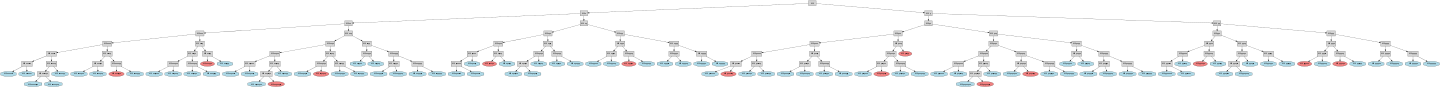

In [ ]:
#25
from IPython.display import Image
Image(filename='ms_lineage_tree.png')

### E Lineage Tree

In [ ]:
#26
print("Generating E tree...")
draw_lineage_tree(e_tree, 'E', filename='e_lineage_tree', format='png')
print("E tree generated.")

Generating E tree...
Lineage tree E saved as e_lineage_tree.png
E tree generated.


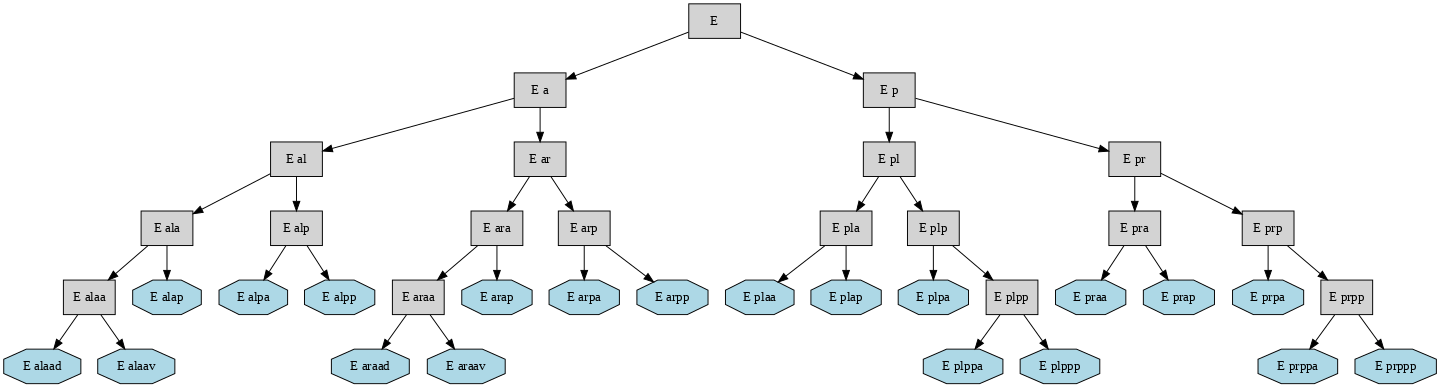

In [ ]:
#27
from IPython.display import Image
Image(filename='e_lineage_tree.png')

In [ ]:
#28
import pandas as pd

# Ensure AB, MS, E lists are defined. If not, these need to be run from prior cells.
# Assuming AB, MS, E are globally available from cell 91228721.

# Remove duplicates by converting to set and back to list
unique_ab_cells = sorted(list(set(AB))) # Use the global AB list
unique_ms_cells = sorted(list(set(MS))) # Use the global MS list
unique_e_cells = sorted(list(set(E)))   # Use the global E list

# Store the unique lists for further use as DataFrames
df_ab = pd.DataFrame(unique_ab_cells, columns=['AB_Cell_Name'])
df_ms = pd.DataFrame(unique_ms_cells, columns=['MS_Cell_Name'])
df_e = pd.DataFrame(unique_e_cells, columns=['E_Cell_Name'])

print("DataFrames df_ab, df_ms, df_e and unique cell lists re-initialized.")

def perform_quality_checks(tree, founder_type):
    """
    Performs a series of quality checks on the lineage tree according to the specified criteria.
    Assumes complementary_map, extract_lineage_info, reconstruct_full_name, get_parent_and_sister_lineage_suffixes
    are available in the global scope.
    """
    issues = []

    # Iterate through all nodes in the tree
    for cell_name, cell_data in tree.items():
        state = cell_data['state']
        children = cell_data['children']
        parent = cell_data['parent']

        # Check 1 & 2: APO and STOP cells should not have children
        if (state == 'APO' or state == 'STOP') and len(children) > 0:
            issues.append(f"ERROR: {founder_type} Cell '{cell_name}' ({state}) has children: {children}. {state} cells should not have children.")

        # Check 3: GO cells must have exactly two complementary children
        if state == 'GO':
            if len(children) != 2:
                issues.append(f"ERROR: {founder_type} GO cell '{cell_name}' has {len(children)} children. Every GO cell must have exactly two complementary children (GO, APO, or STOP).")

            if len(children) == 2:
                child1, child2 = sorted(list(children)) # Sort for consistent order

                # Extract suffixes for complementarity check
                child1_suffix, _ = extract_lineage_info(child1, founder_type)
                child2_suffix, _ = extract_lineage_info(child2, founder_type)

                if child1_suffix and child2_suffix:
                    # Get the expected sister suffix for child1
                    _, expected_sister_suffix_for_child1 = get_parent_and_sister_lineage_suffixes(child1_suffix)

                    # Get the expected sister suffix for child2
                    _, expected_sister_suffix_for_child2 = get_parent_and_sister_lineage_suffixes(child2_suffix)

                    # Check for complementarity: child2's suffix should be the expected sister of child1's suffix
                    # AND child1's suffix should be the expected sister of child2's suffix (mutual complementarity)
                    if not (child2_suffix == expected_sister_suffix_for_child1 and \
                            child1_suffix == expected_sister_suffix_for_child2):
                        issues.append(f"ERROR: {founder_type} GO cell '{cell_name}' has children '{child1}' and '{child2}' which are not complementary. Expected sister for '{child1_suffix}' is '{expected_sister_suffix_for_child1}', but found '{child2_suffix}'. And expected sister for '{child2_suffix}' is '{expected_sister_suffix_for_child2}', but found '{child1_suffix}'.")
                else:
                    # This implies an issue if children of a GO cell don't have proper suffixes (e.g., if a child is the founder itself).
                    issues.append(f"ERROR: {founder_type} GO cell '{cell_name}' has children '{child1}' and '{child2}' but one or both lack proper lineage suffixes required for complementarity check.")


        # Check 4 & 5: Parent-child naming consistency
        # Every non-root node must have a parent, and its name must be derived correctly.
        if cell_name != founder_type: # The founder cell (root) does not have a parent
            if parent is None:
                 issues.append(f"ERROR: {founder_type} Cell '{cell_name}' has no parent, but it is not the founder cell '{founder_type}'. Every non-root node must have a parent.")
            else:
                cell_suffix, _ = extract_lineage_info(cell_name, founder_type)

                # Derive parent suffix from current cell's suffix
                derived_parent_suffix, _ = get_parent_and_sister_lineage_suffixes(cell_suffix)

                # Get actual parent suffix from its full name
                actual_parent_suffix, _ = extract_lineage_info(parent, founder_type)

                if derived_parent_suffix != actual_parent_suffix:
                    issues.append(f"ERROR: {founder_type} Cell '{cell_name}' (child of '{parent}') has parent suffix '{derived_parent_suffix}' derived from its own name, but actual parent suffix is '{actual_parent_suffix}'. Parent name must be equal to child name without the last character.")

    return issues

print("--- Performing Quality Checks on Lineage Trees ---")

ab_issues = perform_quality_checks(ab_tree, 'AB')
ms_issues = perform_quality_checks(ms_tree, 'MS')
e_issues = perform_quality_checks(e_tree, 'E')

print("\n--- AB Lineage Quality Check Results ---")
if ab_issues:
    for issue in ab_issues:
        print(issue)
else:
    print("No issues found for AB lineage.")

print("\n--- MS Lineage Quality Check Results ---")
if ms_issues:
    for issue in ms_issues:
        print(issue)
else:
    print("No issues found for MS lineage.")

print("\n--- E Lineage Quality Check Results ---")
if e_issues:
    for issue in e_issues:
        print(issue)
else:
    print("No issues found for E lineage.")

DataFrames df_ab, df_ms, df_e and unique cell lists re-initialized.
--- Performing Quality Checks on Lineage Trees ---

--- AB Lineage Quality Check Results ---
No issues found for AB lineage.

--- MS Lineage Quality Check Results ---
No issues found for MS lineage.

--- E Lineage Quality Check Results ---
No issues found for E lineage.


In [ ]:
#29
count_ab_cells_less_than_10_chars = 0
for cell_name in unique_ab_cells:
    if len(cell_name) < 10:
        count_ab_cells_less_than_10_chars += 1

print(f"Number of AB lineage cells with name less than 10 characters: {count_ab_cells_less_than_10_chars}")

Number of AB lineage cells with name less than 10 characters: 0


In [ ]:
#30
import pandas as pd

# 1. Definition of the tree and behavioral profiles of the 8 founder cells
# Each profile maps the path from the 8E level to the final configuration of the intestinal rings
subtree_data = {
    # ANTERIOR LINEAGE (Derived from Ea)
    "Eal_ant": {
        "cell_name": "Eala", "position": "Anterior Left",
        "destination": "int1 (ad, av) + int2", "division_profile": ["GO", "asymmetric_GO"],
        "final_cell_count": 3
    },
    "Eal_post": {
        "cell_name": "Ealp", "position": "Anterior Left",
        "destination": "int3 + int4", "division_profile": ["GO", "STOP"],
        "final_cell_count": 2
    },
    "Ear_ant": {
        "cell_name": "Eara", "position": "Anterior Right",
        "destination": "int1 (ad, av) + int2", "division_profile": ["GO", "asymmetric_GO"],
        "final_cell_count": 3
    },
    "Ear_post": {
        "cell_name": "Earp", "position": "Anterior Right",
        "destination": "int3 + int4", "division_profile": ["GO", "STOP"],
        "final_cell_count": 2
    },

    # POSTERIOR LINEAGE (Derived from Ep)
    "Epl_ant": {
        "cell_name": "Epla", "position": "Posterior Left",
        "destination": "int5 + int6", "division_profile": ["GO", "STOP"],
        "final_cell_count": 2
    },
    "Epl_post": {
        "cell_name": "Eplp", "position": "Posterior Left",
        "destination": "int7 + int8 + int9 (ha, hp)", "division_profile": ["GO", "asymmetric_GO"],
        "final_cell_count": 3
    },
    "Epr_ant": {
        "cell_name": "Epra", "position": "Posterior Right",
        "destination": "int5 + int6", "division_profile": ["GO", "STOP"],
        "final_cell_count": 2
    },
    "Epr_post": {
        "cell_name": "Eprp", "position": "Posterior Right",
        "destination": "int7 + int8 + int9 (ha, hp)", "division_profile": ["GO", "asymmetric_GO"],
        "final_cell_count": 3
    }
}

# 2. Conversion to DataFrame for analysis
df_subtrees = pd.DataFrame.from_dict(subtree_data, orient='index')

# 3. Automatic classification of equivalent subtrees
# Grouping by division profile tuple (biological behavior)
df_subtrees['group_id'] = df_subtrees.groupby(
    df_subtrees['division_profile'].map(tuple)
).ngroup()

print("--- CLASSIFICATION OF THE 8 FOUNDER ROOTS ---")
for group_id, cluster in df_subtrees.groupby('group_id'):
    print(f"\nEquivalent Group {group_id + 1}:")
    print(f"  Behavior Profile: {' -> '.join(cluster['division_profile'].iloc[0])}")
    print(f"  Number of final cells produced: {cluster['final_cell_count'].iloc[0]}")
    print(f"  Included Roots: {list(cluster['cell_name'])} ({list(cluster['position'])})")
    print(f"  Assigned Target Rings: {list(cluster['destination'])}")

--- CLASSIFICATION OF THE 8 FOUNDER ROOTS ---

Equivalent Group 1:
  Behavior Profile: GO -> STOP
  Number of final cells produced: 2
  Included Roots: ['Ealp', 'Earp', 'Epla', 'Epra'] (['Anterior Left', 'Anterior Right', 'Posterior Left', 'Posterior Right'])
  Assigned Target Rings: ['int3 + int4', 'int3 + int4', 'int5 + int6', 'int5 + int6']

Equivalent Group 2:
  Behavior Profile: GO -> asymmetric_GO
  Number of final cells produced: 3
  Included Roots: ['Eala', 'Eara', 'Eplp', 'Eprp'] (['Anterior Left', 'Anterior Right', 'Posterior Left', 'Posterior Right'])
  Assigned Target Rings: ['int1 (ad, av) + int2', 'int1 (ad, av) + int2', 'int7 + int8 + int9 (ha, hp)', 'int7 + int8 + int9 (ha, hp)']


In [ ]:
#31
import re
import pandas as pd

def find_and_map_filtered_trs(dna_sequence, min_monomer_length=4, max_monomer_length=12, min_copies=3):
    """
    Searches for Tandem Repeats (TRs) in DNA, excluding monomeric (1bp),
    dimeric (2bp), and trimeric (3bp) sequences. Calculates real parameters for each TR.
    """
    # Set min_monomer_length directly to 4 to exclude 1, 2, and 3 bp upfront
    if min_monomer_length < 4:
        min_monomer_length = 4

    pattern = rf"(([ACTG]{{{min_monomer_length},{max_monomer_length}}})\2{{{min_copies-1},}})"

    found_trs = []

    for match in re.finditer(pattern, dna_sequence, re.IGNORECASE):
        total_sequence = match.group(1).upper()
        candidate_monomer = match.group(2).upper()

        # --- INTRA-MONOMER DEGENERATION CHECK ---
        # We check if the found monomer is itself a hidden repeat of 1, 2, or 3 bases
        # Example: "ATATAT" (6bp) would be seen as a 6-base monomer, but it's a degenerate dimer.
        is_degenerate = False
        for k in range(1, 4):
            # If the monomer is divisible by k, we check its sub-repeat
            if len(candidate_monomer) % k == 0:
                sub_unit = candidate_monomer[:k]
                if sub_unit * (len(candidate_monomer) // k) == candidate_monomer:
                    is_degenerate = True
                    break

        if is_degenerate:
            continue  # Skip and exclude mono, di, and tri-meric sequences

        start_pos = match.start()
        end_pos = match.end()
        monomer_length = len(candidate_monomer)
        num_repeats = len(total_sequence) // monomer_length

        found_trs.append({
            "Position_Start": start_pos,
            "Position_End": end_pos,
            "Monomer": candidate_monomer,
            "Monomer_Length": monomer_length,
            "Number_of_Repeats": num_repeats
        })

    df_tr = pd.DataFrame(found_trs)
    return df_tr

# --- FILTER VALIDATION TEST ---
# The string contains:
# 1. A 1bp monomer ("AAAAA...") -> MUST BE EXCLUDED
# 2. A 2bp monomer ("ATATATAT") -> MUST BE EXCLUDED
# 3. A 3bp monomer ("ACGACGACG") -> MUST BE EXCLUDED
# 4. A 6bp monomer ("TTAGGCTTAGGCTTAGGC") -> MUST BE ACCEPTED
# 5. A 4bp monomer ("CCGACCGACCGA") -> MUST BE ACCEPTED
test_sequence = "A"*30 + "AT"*10 + "ACG"*8 + "TTAGGCTTAGGCTTAGGC" + "CCGACCGACCGA"

df_tr_results = find_and_map_filtered_trs(test_sequence)
print("--- VALID TRs DETECTED (FILTERED FROM MONO/DI/TRI-MERS) ---")
print(df_tr_results)

--- VALID TRs DETECTED (FILTERED FROM MONO/DI/TRI-MERS) ---
   Position_Start  Position_End Monomer  Monomer_Length  Number_of_Repeats
0              74            92  TTAGGC               6                  3
1              92           104    CCGA               4                  3
